# Replication of Angrist and Lavy (1999): Using Maimonides' Rule to estimate the effect of class size on Scholastic achievement

Bruce Zhou, Spring 2026

This notebook is my replication of the following paper:
> Angrist, J. D., & Lavy, V. (1999). Using Maimonides' rule to estimate the effect of class size on scholastic achievement. The Quarterly Journal of Economics, 114(2), 533–575.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from great_tables import GT, style, loc
import importlib

from auxiliary import dag
from auxiliary.tables import TableGenerator
from auxiliary.plots import PlotGenerator

# I. Introduction

Angrist and Lavy examine the effect of class size on student achievement. As the easiest variable to manipulate, class size has been at the center of academic and political debate for centuries. However, simple correlations and ordinary least square (OLS) estimates are biased due to onobservable school inputs like socioeconomic background. To reduce baseline bias, Angrist and Lavy implement the Maimonides' rule.

Dating back to the twelfth century, Rabbinic scholar Maimonides proposed a principle: "If there are more (students) than forty, two teachers must be appointed." According to the rule, class size increases along with enrollment until the enrolled students reach 40. When the 41th student is enrolled, the class size must be split to an average of 20.5. Similarly, when enrollment reaches 81, 3 classes must be divided, and the average class size is 27. This nonlinear and nonmonotonic relationship, known as Maimonides' rule, though not stictly obeyed, has generally been used to determine the class division of public schools in Israel since 1969.

To isolate the causal effect of class size from confounding factors like socioeconomic design,  Angrist and Lavy use a fuzzy regression-discontinuity design (RDD). They construct a instrumental variable, $f_{sc}$, based on the sawtooth function induced by Maimonides' rule, the nonlinearity of which allows them to partial out enrollment effects. Observing 1991 national test data in Israeli elementary schools, they find out that small classes lead to an increase in student achievement for 4th and 5th graders, particularly for students who are socioeconomically more disadvantaged.

# II. Data

The original test data comes from a national test on reading and math for 4th and 5th graders. It is conducted by the National Center for Education on Israeli elementary schools in 1991. Populations of schools are from the Central Bureau of Statistics Census of Schools 1991. Angrist and Lavy filter the dataset so it excludes Arab schools and Jewish religious schools, because they were not tested on reading in 1991.

While the original study included a 1992 sample of 3rd graders, this replication excludes it due to the compromised test conditions. Specifically, the 3rd graders were subject to systematic test preparation, resulting in ceiling effects and insignificant findings. Consequently, this replication focuses on the sample of 4th and 5th graders, which provide a more robust environment for examining the causal effect of class size.

The dataset also includes a school-level index of students' socioeconomic status, which is called percentage disadvantaged (PD). Higher PD means students in that school are generally poorer.

In [25]:
df_grade4 = pd.read_stata(r"F:\python-files\econ-481\project-business-decisions-didida2007\data\final4.dta")
df_grade5 = pd.read_stata(r"F:\python-files\econ-481\project-business-decisions-didida2007\data\final5.dta")

In [26]:
class FullAnalysis(TableGenerator, PlotGenerator):
    """Combine table-generation and plotting tools for one analysis object."""

df_4th = FullAnalysis(df_grade4)
df_5th = FullAnalysis(df_grade5)

The table below reports the descriptive statistics of more than $2000$ classes in the sample. While the average class size is $30$, $10\%$ of classes have students less than $21$, and $10\%$ of classes have students more than $38$, both of which violating Maimonides' rule. The average score distribution for 4th and 5th graders are similar.

In [27]:
df_5th.descriptive_table(df_4th)

GT(_tbl_data=                                             Variable  mean   std   q10   q25  \
0                                      A. Full sample                           
1   5th grade (2029 classes, 1004 schools, tested ...                           
2                                          Class size  30.0   6.6    21    26   
3                                          Enrollment  77.9  39.1    31    50   
4                               Percent disadvantaged  14.1  13.5     2     4   
5                                        Reading size  27.3   6.6    19    23   
6                                           Math size  27.7   6.7    19    23   
7                                      Average verbal  74.4   8.1  64.2  69.9   
8                                        Average math  67.3  10.0  54.9  61.1   
9                                                                               
10  4th grade (2059 classes, 1016 schools, tested ...                           
11                                         Class size  30.3   6.4    22    26   
12                                         Enrollment  78.4  37.9    30    51   
13                              Percent disadvantaged  13.8  13.4     2     4   
14                                       Reading size  27.7   6.6    19    24   
15                                          Math size  28.1   6.6    19    24   
16                                     Average verbal  72.5   8.0  62.2  67.7   
17                                       Average math  68.9   8.8  57.5  63.6   

     q50   q75   q90  
0                     
1                     
2     31    35    38  
3     72   100   128  
4     10    19    35  
5     28    32    36  
6     28    33    36  
7   75.4  79.8  83.3  
8   67.8  74.1  79.4  
9                     
10                    
11    31    35    38  
12    74   102   128  
13     9    19    35  
14    28    32    36  
15    29    33    36  
16  73.3  78.2  82.0  
17  69.3  75.0  79.4  , _body=<great_tables._gt_data.Body object at 0x0000028B49132C90>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='center', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='S.D.', column_align='center', column_width=None), ColInfo(var='q10', type=<ColInfoTypeEnum.default: 1>, column_label='0.10', column_align='center', column_width=None), ColInfo(var='q25', type=<ColInfoTypeEnum.default: 1>, column_label='0.25', column_align='center', column_width=None), ColInfo(var='q50', type=<ColInfoTypeEnum.default: 1>, column_label='0.50', column_align='center', column_width=None), ColInfo(var='q75', type=<ColInfoTypeEnum.default: 1>, column_label='0.75', column_align='center', column_width=None), ColInfo(var='q90', type=<ColInfoTypeEnum.default: 1>, column_label='0.90', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028B2155F250>, _spanners=Spanners([SpannerInfo(spanner_id='Quantiles', spanner_level=0, spanner_label='Quantiles', spanner_units=None, spanner_pattern=None, vars=['q10', 'q25', 'q50', 'q75', 'q90'], built=None)]), _heading=Heading(title='UNWEIGHTED DESCRIPTIVE STATISTICS', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000028B4B88FCD0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000028B4C133B10>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000028B4B9C9B50>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=Opt

Angrist and Lavy also display a discontinuity sample, which only includes schools with enrollment within the set of intervals ${[36, 45], [76, 85], [116, 125]}$. Since the Maimonides' rule induce discontinuities, the sample can be used to identify the true class size effect. Although the average class size is a bit larger in this sample, other characteristics are highly similar to the full sample.

In [28]:
df_5th.discontinuity_table(df_4th)

GT(_tbl_data=                Variable  mean1  std1  mean2  std2
0             Class size   30.9   7.4   31.2   7.3
1             Enrollment   76.4  29.5   78.4  30.0
2  Percent disadvantaged   13.6  13.2   12.9  12.4
3           Reading size   28.2   7.3   28.3   7.7
4              Math size   28.6   7.4   28.7   7.7
5         Average verbal   74.5   8.2   72.5   7.8
6           Average math   67.1  10.2   68.7   9.1, _body=<great_tables._gt_data.Body object at 0x0000028B4916AAD0>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='mean1', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='center', column_width=None), ColInfo(var='std1', type=<ColInfoTypeEnum.default: 1>, column_label='S.D.', column_align='center', column_width=None), ColInfo(var='mean2', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='center', column_width=None), ColInfo(var='std2', type=<ColInfoTypeEnum.default: 1>, column_label='S.D.', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028B4B8BC5F0>, _spanners=Spanners([SpannerInfo(spanner_id='5th grade (2029 classes, 1004 schools, tested in 1991)', spanner_level=0, spanner_label='5th grade (2029 classes, 1004 schools, tested in 1991)', spanner_units=None, spanner_pattern=None, vars=['mean1', 'std1'], built=None), SpannerInfo(spanner_id='4th grade (2059 classes, 1016 schools, tested in 1991)', spanner_level=0, spanner_label='4th grade (2059 classes, 1016 schools, tested in 1991)', spanner_units=None, spanner_pattern=None, vars=['mean2', 'std2'], built=None)]), _heading=Heading(title='+/-5 Discontinuity Sample', subtitle='Enrollment 36-45, 76-85, 116-124', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000028B4C1331B0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000028B4B7D7800>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000028B4B8BC230>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', val

# III. Graphical Analysis

The class-size function induced from Maimonides' rule can be stated as follows. Let $e_s$ denote the enrollment of students in school $s$ in a certain grade at the beginning of a year. Let $f_{sc}$ denote the class size predicted by Maimonides' rule in class $c$, school $s$. Assuming classes are divided into equal sizes in the same school:
$$
f_{sc}=\frac{e_s}{\lfloor((e_s-1)/40)+1\rfloor} \tag{1}
$$
Although many schools do not strictly obey the rule - only about one quarter of classes in schools with two classes per grade are of equal size - actual class size and $f_{sc}$ are still correlated. In the following figures, Angrist and Lavy plot the average class size by enrollment for 4th and 5th graders, along with the class-size function. Horizontal dashed gray lines mark the corners of the function.

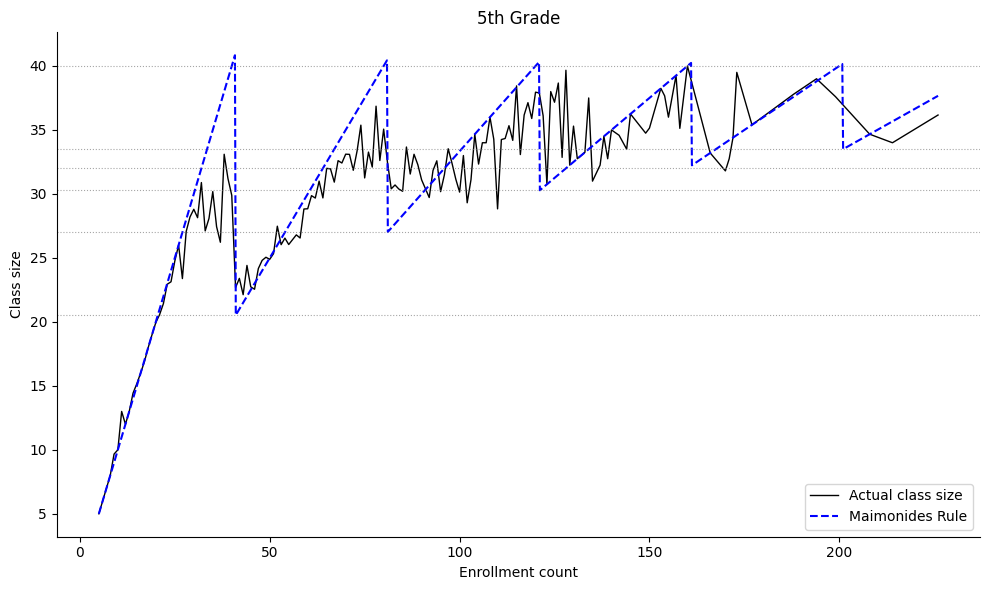

In [29]:
df_5th.plot_maimonides_sawtooth()

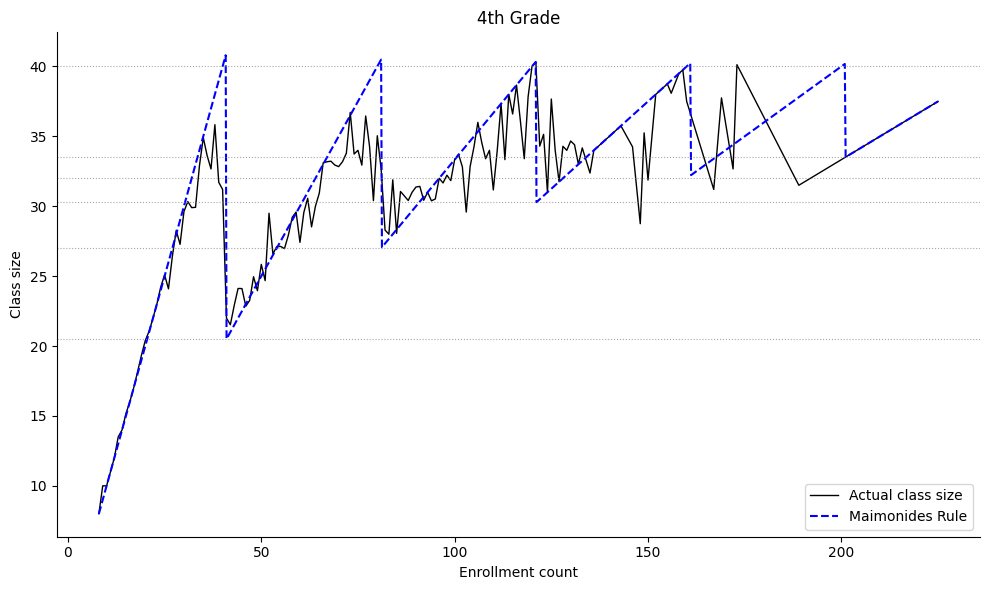

In [30]:
df_4th.plot_maimonides_sawtooth()

When enrollment is not at multiples of $40$, average class size increases. But when enrollment reaches multiples of $40$, class size drops drastically. Interestingly, class size never reaches $40$ when enrollment is lower than $120$, even at multiples of $40$ as Maimonides' rule predict. Angrist and Lavy explain that this is due to schools being able to afford more classes and parents manipulating class size. Class size also drops less at corners than the rule predicts, because enrollment changes along the year.

Angrist and Lavy also find that the class-size function is negatively correlated with average test scores. This can be seen in the following figures.

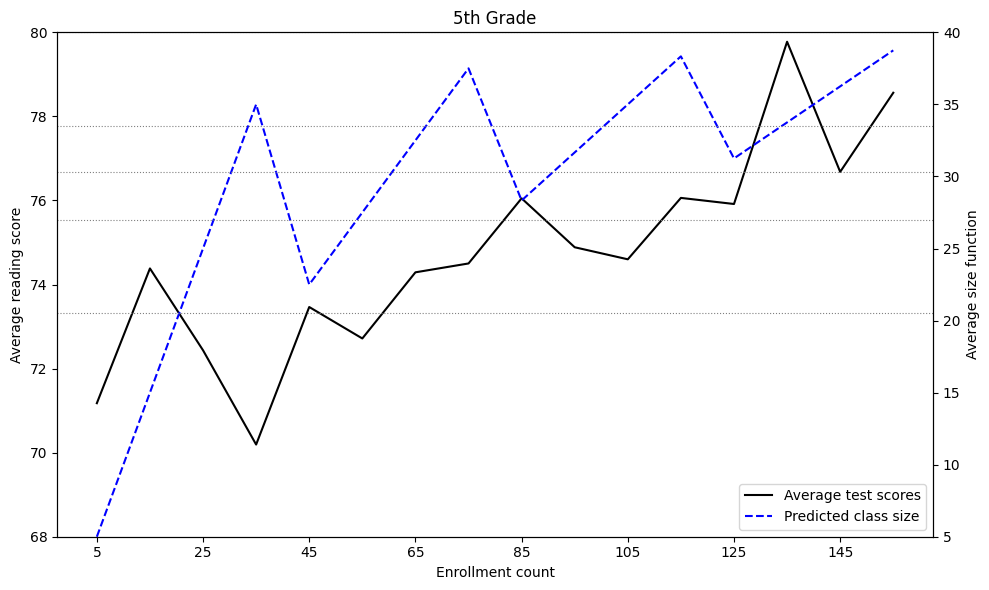

In [31]:
df_5th.plot_scores_vs_predicted_size()

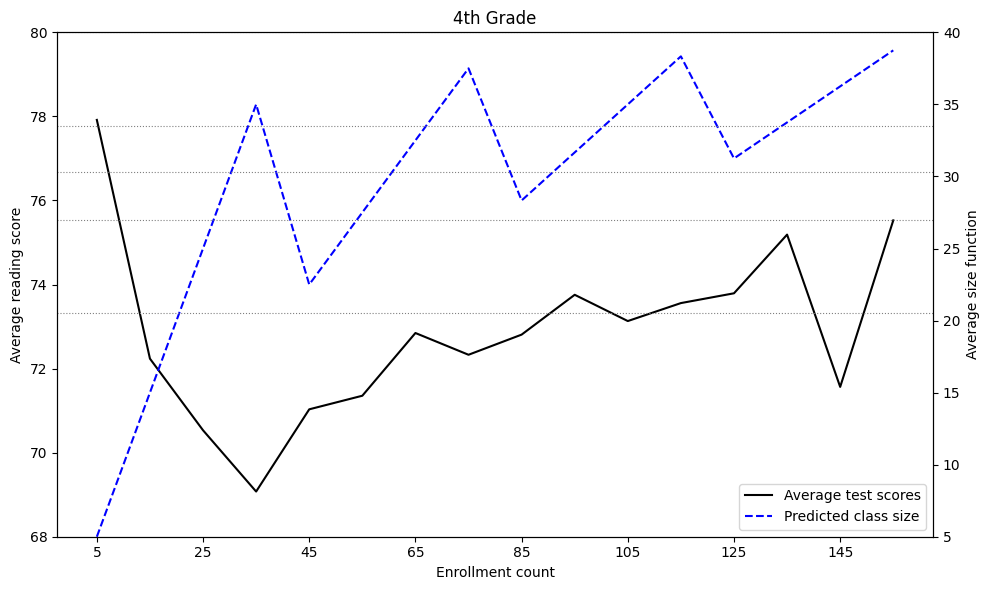

In [32]:
df_4th.plot_scores_vs_predicted_size()

From the figures, average reading scores seem to have a positve correlation with enrollment. Angrist and Lavy attribute this phenomenon partly to the fact that larger schools are usaully located in more prosperous city areas with lower PD. To control the "trend association" of enrollment and PD, Angrist and Lavy regress average reading scores and the class size function on enrollment and PD, then plot the residuals.

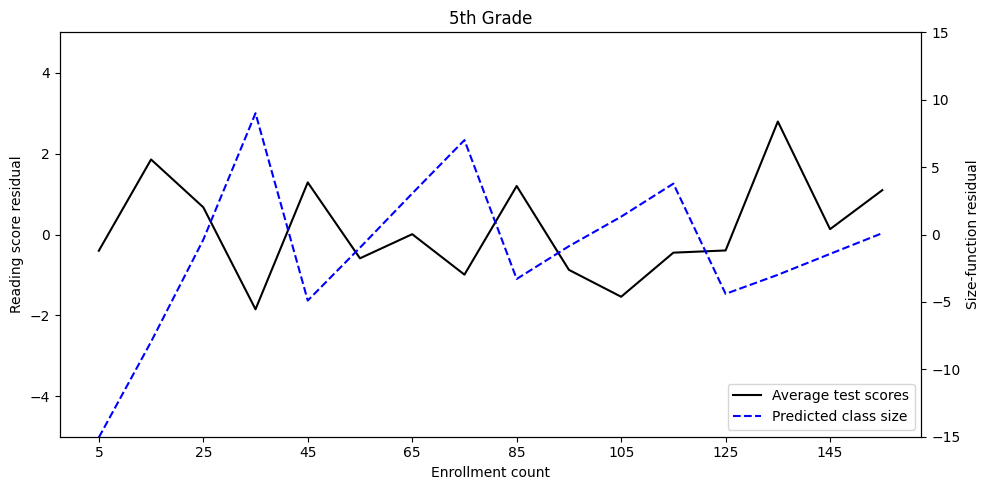

In [33]:
df_5th.plot_residual()

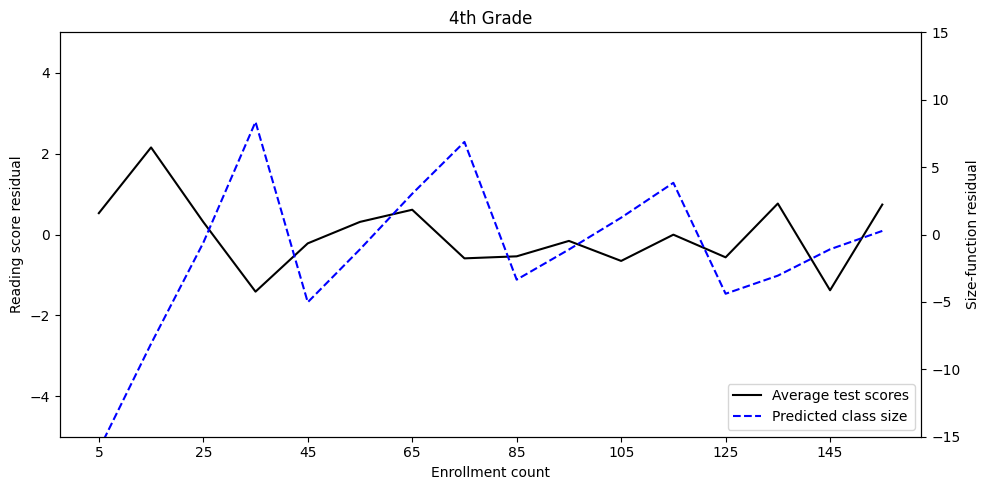

In [34]:
df_4th.plot_residual()

After detrending enrollment and PD, the enrollment effect vanishes, and average reading score is still negatively correlated with the class size function. Angrist and Lavy regressed the detrended average reading score on the detrended class size function, and find a negative slope of $-0.22$ for 5th graders and $-0.11$ for 4th graders. This means decreasing predicted class size by $1$ point increases average reading score by $0.22$ points.

In [35]:
(resid_reg_5th, bins_5th) = df_5th.detrended_regression()
(resid_reg_4th, bins_4th) = df_4th.detrended_regression()

pd.DataFrame(
    {
        "grade": ["5th", "4th"],
        "slope_on_residual_size": [resid_reg_5th.params.iloc[0], resid_reg_4th.params.iloc[0]],
        "robust_se": [resid_reg_5th.bse.iloc[0], resid_reg_4th.bse.iloc[0]],
    }
)

,grade,slope_on_residual_size,robust_se
0,5th,-0.101315,0.066343
1,4th,-0.068292,0.035844


> Technical Note:
> The regressed slopes in the replication are of the same sign as the original study. The ~ 50% deviation is attributed to the high sensitivity of residualized bin means. While the authors utilize residuals to visualize the correlation, the primary causal effect is revealed in the 2SLS part, which remain robust in this replication.

# IV. Identification

The figures suggest evidence of correlation between the predicted class size and student achievement, but they do not provide a formal framwork for causal inference. To estimate causal relationships, Angrist and Lavy establish the following pontential outcomes equation:
$$
y_{isc}=X'_s\beta+n_{sc}\alpha+\eta_s+\mu_c +\varepsilon_{isc} \tag{2}
$$
$y_{isc}$ denotes student $i$'s score in class $c$, school $s$. $X_s$ is a vector of school characteristics, sometimes including functions of enrollment. $n_{sc}$ is the size of the class. $\eta_s$, $\mu_c$, and $\varepsilon_{isc}$ are the i.i.d components of the school, class, and student.

Since $n_{sc}$ is not selected randomly conditioned on $X_s$, the OLS estimate of $\alpha$ is subject to selection bias, and do not have a valid causal interpretation. Since only class-level data is available, Angrist and Lavy revise the equation to capture class-level average score and errors:
$$
\bar{y}_{sc}=X'_s\beta+n_{sc}\alpha+\eta_s+[\mu_c +\bar{\varepsilon}_{sc}] \tag{3}
$$
Angrist and Lavy claim that the data is not homoskedastic due to random-effects error of $\eta_s$. Therefore, they will report both the OLS and IV estimates, and standard errors corrected for intraschool correlation by formulas in Moulton (1986),which are 10-15 percent larger than usual standard errors.

The following graph shows the causal relationship between class size and test scores:

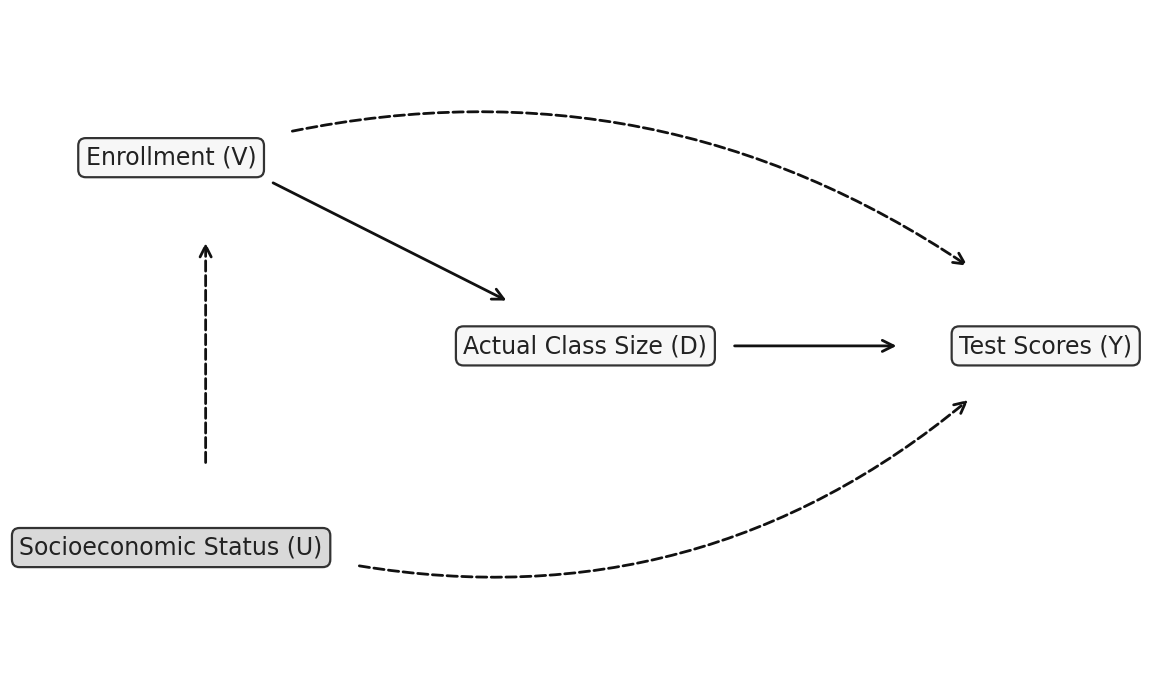

In [36]:
importlib.reload(dag)
fig_no_z, ax_no_z = dag.plot_identification_dag_without_z(show=True)

Actual class size ($D$), referred to as $n_{sc}$ $\Rightarrow$ Test scores ($Y$) is the total effect Angrist and Lavy try to measure.

Enrollment ($V$), referred to as $e_s$, is the observable confounding factor which directly affects class size. It also affects test scores through the backdoor $V \Rightarrow Y$.For example, better school may faces increasing demand, and more-educated parents may avoid large schools if they are perceived as overcrowded.

Socioeconomic status ($U$) is the unobservable factor which directly affects test scores by the quality of schools: $U \Rightarrow Y$. It also affects test score by the influencing the intermediate factor enrollment: $U \Rightarrow V \Rightarrow Y$. In Israel, cities usually have larger schools than rural areas. Thus, PD is negatively correlated with enrollment.

To block the backdoors, Angrist and Lavy implement the surrogate instrumental variable, Maimonides' rule ($Z$), referred to as $f_{sc}$. It is a deterministic function of $e_s$, so controlling $f_{sc}$ controls enrollment. It is also uncorrelated with PD, satisfying the exclusion restriction. Enrollment is correlated with class size, so the relevance assumption is also satisfied.

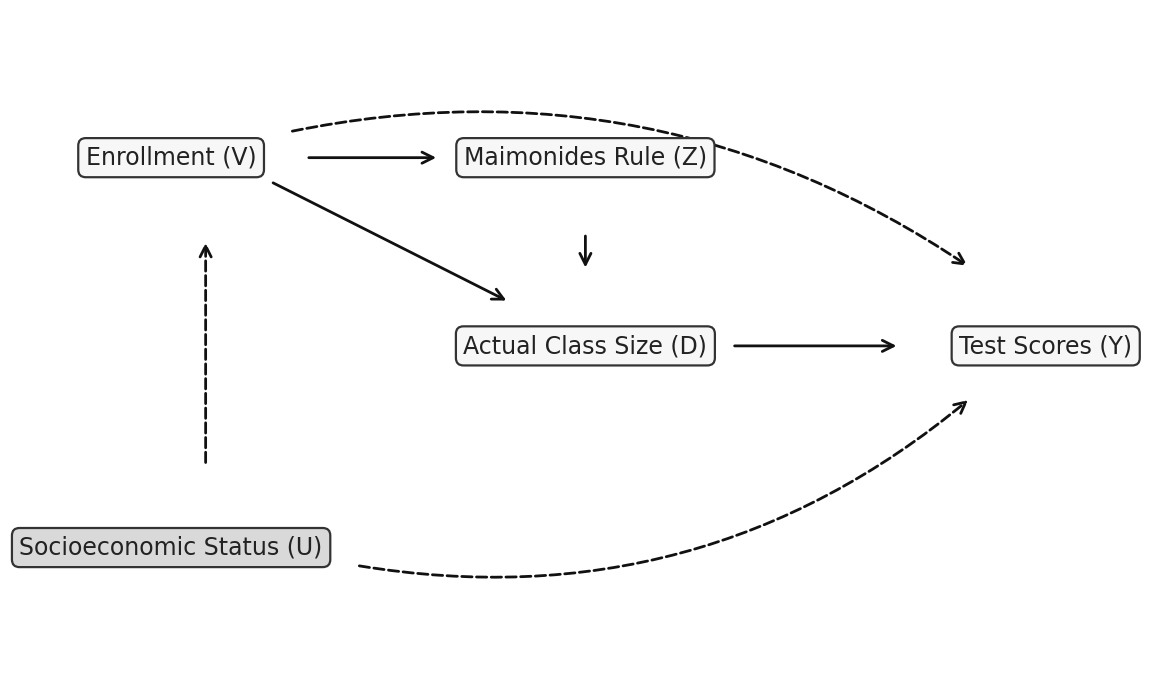

In [37]:
fig_full, ax_full = dag.plot_identification_dag(show=True)

The equation below is the first-stage relationship:
$$
n_{sc}=X'_s\pi_0+f_{sc}\pi_1+\xi_{sc} \tag{4}
$$
Angrist and Lavy specify the effects of enrollment on test scores into two categories. Smooth effects, represented by functions of enrollment in $X_s$, reflect school inputs like better facilities. Jagged effects, which is represented by discontinuities in $f_{sc}$, reflects the true class size effect. The residual $\xi_{sc}$ captures remaining factors correlated with enrollment.

By including a piecewise linear trend function in $X'_s$, the smooth effect backdoor $V \Rightarrow Y$ is "partialled out". This leaves only the jagged effect variation in enrollment to be identified through $f_{sc}$. Meanwhile, Angrist and Lavy explicitly control PD in the regression of $X'_s$, so that the other backdoor $U \Rightarrow Y$ is also blocked.

One crucial assumption is that all smooth effects are adequately controlled by $X'_s\beta$ in (3), and "partialled out" by $X'_s\pi_0$ in (4). However, this assumption is untestable. Therefore, Angrist and Lavy experiment with a wide range of alternative specifications.

Another identifying assumption is that parents do not exploit Maimonides' rule by selectively placing their children in schools within the $[41,45]$ bracket, to benefit from small classes. Angrist and Lavy argue that enrollment may change when the school starts, so it may fall below $41$. Free transfer between schools are not allowed, and public schools are rare. Thus, the assumption can be viewed as valid.

# V. Estimates

> Technical Note: All regression results are slightly different ($\pm 10\%$) from the original study, which is attributed to different algorithms for matrix inversion and using robust standard errors instead of Moulton correction standard errors.

In [38]:
df_5th.custom_ols_table(df_4th)

GT(_tbl_data=               Regressors     (1)     (2)     (3)     (4)     (5)     (6)  \
0              Mean score            74.4                    67.3           
1                  (s.d.)           (8.1)                  (10.0)           
2              Regressors                                                   
3              Class size    .220   -.028   -.024    .324    .087    .023   
4                          (.027)  (.024)  (.029)  (.033)  (.032)  (.039)   
5   Percent disadvantaged           -.346   -.346           -.331   -.322   
6                                  (.012)  (.012)          (.016)  (.016)   
7              Enrollment                   -.001                    .019   
8                                          (.005)                  (.007)   
9                Root MSE    7.95    6.64    6.64    9.80    8.87    8.85   
10                     R2    .032    .325    .325    .045    .219    .222   
11                      N           2,024                   2,024           

       (7)     (8)     (9)    (10)    (11)    (12)  
0             72.5                    68.9          
1            (8.0)                   (8.8)          
2                                                   
3     .135   -.054   -.042    .211    .050    .003  
4   (.027)  (.024)  (.028)  (.030)  (.028)  (.033)  
5            -.339   -.341           -.288   -.281  
6           (.011)  (.012)          (.013)  (.014)  
7                    -.004                    .015  
8                   (.005)                  (.006)  
9     7.94    6.64    6.64    8.67    7.84    7.83  
10    .012    .309    .309    .024    .202    .205  
11           2,055                   2,055          , _body=<great_tables._gt_data.Body object at 0x0000028B49199B80>, _boxhead=Boxhead([ColInfo(var='Regressors', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='(1)', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='(2)', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='(3)', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='(4)', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='(5)', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='(6)', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None), ColInfo(var='(7)', type=<ColInfoTypeEnum.default: 1>, column_label='(7)', column_align='center', column_width=None), ColInfo(var='(8)', type=<ColInfoTypeEnum.default: 1>, column_label='(8)', column_align='center', column_width=None), ColInfo(var='(9)', type=<ColInfoTypeEnum.default: 1>, column_label='(9)', column_align='center', column_width=None), ColInfo(var='(10)', type=<ColInfoTypeEnum.default: 1>, column_label='(10)', column_align='center', column_width=None), ColInfo(var='(11)', type=<ColInfoTypeEnum.default: 1>, column_label='(11)', column_align='center', column_width=None), ColInfo(var='(12)', type=<ColInfoTypeEnum.default: 1>, column_label='(12)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028B4957C9B0>, _spanners=Spanners([SpannerInfo(spanner_id='5th Grade', spanner_level=0, spanner_label='5th Grade', spanner_units=None, spanner_pattern=None, vars=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)'], built=None), SpannerInfo(spanner_id='4th Grade', spanner_level=0, spanner_label='4th Grade', spanner_units=None, spanner_pattern=None, vars=['(7)', '(8)', '(9)', '(10)', '(11)', '(12)'], built=None)]), _heading=Heading(title='OLS ESTIMATES FOR 1991', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000028B4926FDD0>, _summary_rows_grand=<great_tables._gt_data.Sum

The table above shows the OLS regression of average reading scores on class size. With no control variable, a positive correlation between reading scores and class size can be observed. After controlling for PD, the correlation vanishes, and in some cases turns negative. For example, estimated class-size effect of 5th graders drops from $0.220$ to $-0.028$. Nevertheless, the effects are relatively insignificant, and controlling for PD does not eliminate selection bias. For example, school principals may group struggling students into smaller classes.

Instrumental variables have the potential to address the problem.

In [39]:
df_5th.custom_reduced_form_table(df_4th)

GT(_tbl_data=                 Regressors     (1)     (2)     (3)     (4)     (5)     (6)  \
0            A. Full sample                                                   
1                     Means            30.0            74.4            67.3   
2                    (s.d.)           (6.6)           (8.1)          (10.0)   
3                      f_sc    .708    .551   -.111   -.153    .002   -.122   
4                            (.017)  (.021)  (.025)  (.031)  (.034)  (.042)   
5     Percent disadvantaged   -.077   -.055   -.356   -.350   -.346   -.328   
6                            (.008)  (.008)  (.011)  (.012)  (.015)  (.016)   
7                Enrollment            .042            .011            .033   
8                                    (.003)          (.005)          (.007)   
9                  Root MSE    4.58    4.42    6.61    6.60    8.89    8.84   
10                       R2    .519    .553    .331    .333    .216    .226   
11                        N           2,029           2,024           2,024   
12  B. Discontinuity sample                                                   
13                    Means            30.9            74.5            67.1   
14                   (s.d.)           (7.4)           (8.2)          (10.2)   
15                     f_sc    .484    .350   -.196   -.199   -.086   -.149   
16                           (.039)  (.040)  (.040)  (.045)  (.056)  (.061)   
17    Percent disadvantaged   -.131   -.069   -.424   -.423   -.436   -.406   
18                           (.022)  (.022)  (.023)  (.025)  (.032)  (.034)   
19               Enrollment            .086            .002            .040   
20                                   (.011)          (.012)          (.016)   
21                 Root MSE    5.96    5.60    6.24    6.25    8.60    8.55   
22                       R2    .361    .437    .421    .421    .296    .305   
23                        N             472             472             472   

       (7)     (8)     (9)    (10)    (11)    (12)  
0                                                   
1             30.3            72.5            68.9  
2            (6.4)           (8.0)           (8.8)  
3     .777    .676   -.085   -.087    .038   -.031  
4   (.016)  (.020)  (.026)  (.032)  (.030)  (.038)  
5    -.053   -.039   -.340   -.339   -.291   -.281  
6   (.007)  (.007)  (.011)  (.012)  (.013)  (.014)  
7             .026            .001            .018  
8           (.003)          (.005)          (.006)  
9     4.27    4.20    6.63    6.63    7.84    7.83  
10    .557    .571    .311    .311    .202    .205  
11           2,059           2,055           2,055  
12                                                  
13            31.2            72.5            68.7  
14           (7.3)           (7.8)           (9.1)  
15    .632    .516   -.060   -.073    .060    .014  
16  (.037)  (.041)  (.044)  (.051)  (.055)  (.063)  
17   -.061   -.022   -.346   -.342   -.301   -.286  
18  (.022)  (.022)  (.026)  (.027)  (.033)  (.034)  
19            .060            .007            .024  
20          (.011)          (.013)          (.016)  
21    5.56    5.36    6.56    6.57    8.25    8.24  
22    .423    .465    .300    .301    .175    .179  
23             417             417             417  , _body=<great_tables._gt_data.Body object at 0x0000028B4985AB20>, _boxhead=Boxhead([ColInfo(var='Regressors', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='(1)', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='(2)', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='(3)', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='(4)', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='(5

The table above shows the reduced-form regression of class size and average test scores on predicted class size $f_{sc}$, controlling for PD and enrollment, over both the full sample and the discontinuity sample. When only PD is controlled for, the instrumental variable estimates of effect of $f_{sc}$ on reading score are negative, while The effect on math score is unclear. After controlling for enrollment, a similar negative effect on math score can be observed. The discontinuity sample is less precise than the full sample due to the N problem, higher volatility, and magnified fuzziness, but it nevertheless follows a similar trend.

Angrist and Lavy state that a major concern of the internal validity of regression-discontinuity designs is whether controls for factors that generate the discontinuity are adequate. As a solution, they include a continuous piecewise linear trend which mimics the class size function by copying its slope in the regression. The trend is defined on the interval $[0, 160]$ as follows:
$$
f(e_s) = \begin{cases} 
e_s & e_s \in [0, 40] \\
20 + (e_s/2) & e_s \in [41, 80] \\
(100/3) + (e_s/3) & e_s \in [81, 120] \\
(130/3) + (e_s/4) & e_s \in [121, 160]
\end{cases}
$$
For example, the slope of (1) in the $[41, 80]$ interval is $1/2$, so the trend also have slope $1/2$. An extra $20$ is added to make sure the trend is continuous. The approach is a utilization of the Frisch-Waugh-Lovell Theorem. By matching the slope of the linear control and the true (jagged) effect, the smooth effect of enrollment is partialled out. Consequently, the instrumental variable $f_{sc}$ is generated solely by discontinuous jumps mandated by Maimonides' rule at multiples of 40, and the jagged effect can be identified by the discontinuities. PD and enrollment can also be dropped from control because all smooth effects have already been captured.

In [40]:
df_5th.custom_twoSLS_table()

GT(_tbl_data=                Regressors     (1)     (2)     (3)     (4)     (5)     (6)  \
0               Mean score            74.4                    74.5           
1                   (s.d.)           (8.1)                   (8.2)           
2               Regressors                                                   
3               Class size   -.156   -.279   -.280   -.194   -.405   -.569   
4                           (.036)  (.059)  (.059)  (.084)  (.091)  (.145)   
5    Percent disadvantaged   -.368   -.365   -.365           -.477   -.462   
6                           (.013)  (.013)  (.013)          (.031)  (.031)   
7               Enrollment            .023    .023                    .051   
8                                   (.007)  (.007)                  (.022)   
9   Enrollment squared/100                    .000                           
10                                          (.003)                           
11  Piecewise linear trend                            .137                   
12                                                  (.025)                   
13                Root MSE    6.69    6.77    6.77    8.08    6.79    7.14   
14                       N           2,024                     472           

       (7)     (8)     (9)    (10)    (11)    (12)  
0                     67.3            67.1          
1                   (10.0)          (10.2)          
2                                                   
3     .003   -.223   -.227   -.194   -.178   -.425  
4   (.048)  (.077)  (.078)  (.103)  (.117)  (.185)  
5    -.345   -.340   -.339           -.459   -.436  
6   (.017)  (.017)  (.017)          (.040)  (.039)  
7             .043    .041                    .077  
8           (.009)  (.009)                  (.028)  
9                     .003                          
10                  (.003)                          
11                            .191                  
12                          (.030)                  
13    8.89    8.94    8.95    9.87    8.80    9.10  
14                   2,024             472          , _body=<great_tables._gt_data.Body object at 0x0000028B49F61630>, _boxhead=Boxhead([ColInfo(var='Regressors', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='(1)', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='(2)', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='(3)', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='(4)', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='(5)', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='(6)', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None), ColInfo(var='(7)', type=<ColInfoTypeEnum.default: 1>, column_label='(7)', column_align='center', column_width=None), ColInfo(var='(8)', type=<ColInfoTypeEnum.default: 1>, column_label='(8)', column_align='center', column_width=None), ColInfo(var='(9)', type=<ColInfoTypeEnum.default: 1>, column_label='(9)', column_align='center', column_width=None), ColInfo(var='(10)', type=<ColInfoTypeEnum.default: 1>, column_label='(10)', column_align='center', column_width=None), ColInfo(var='(11)', type=<ColInfoTypeEnum.default: 1>, column_label='(11)', column_align='center', column_width=None), ColInfo(var='(12)', type=<ColInfoTypeEnum.default: 1>, column_label='(12)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028B49289E10>, _spanners=Spanners([SpannerInfo(spanner_id='Reading comprehension', spanner_level=0, spanner_label='Reading comprehension', spanner_units=None, spanner_pattern=None, vars=['(1)', '(2)', '(3)', '(4)', '(5)', '(6

In [41]:
df_4th.custom_twoSLS_table()

GT(_tbl_data=                Regressors     (1)     (2)     (3)     (4)     (5)     (6)  \
0               Mean score            72.5                    72.5           
1                   (s.d.)           (8.0)                   (7.8)           
2               Regressors                                                   
3               Class size   -.109   -.130   -.121   -.144   -.095   -.141   
4                           (.033)  (.048)  (.049)  (.067)  (.070)  (.099)   
5    Percent disadvantaged   -.346   -.344   -.346           -.352   -.345   
6                           (.012)  (.012)  (.012)          (.027)  (.028)   
7               Enrollment            .004    .011                    .015   
8                                   (.006)  (.007)                  (.017)   
9   Enrollment squared/100                   -.007                           
10                                          (.003)                           
11  Piecewise linear trend                            .101                   
12                                                  (.019)                   
13                Root MSE    6.65    6.66    6.65    7.97    6.63    6.68   
14                       N           2,055                     417           

       (7)     (8)     (9)    (10)    (11)    (12)  
0                     68.9            68.7          
1                    (8.8)           (9.1)          
2                                                   
3     .050   -.046   -.039   -.090    .095    .027  
4   (.039)  (.057)  (.057)  (.072)  (.087)  (.122)  
5    -.288   -.283   -.284           -.296   -.285  
6   (.014)  (.014)  (.014)          (.033)  (.034)  
7             .019    .025                    .022  
8           (.007)  (.008)                  (.021)  
9                    -.005                          
10                  (.003)                          
11                            .128                  
12                          (.021)                  
13    7.84    7.83    7.83    8.62    8.22    8.23  
14                   2,055             417          , _body=<great_tables._gt_data.Body object at 0x0000028B49F61400>, _boxhead=Boxhead([ColInfo(var='Regressors', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='(1)', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='(2)', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='(3)', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='(4)', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='(5)', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='(6)', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None), ColInfo(var='(7)', type=<ColInfoTypeEnum.default: 1>, column_label='(7)', column_align='center', column_width=None), ColInfo(var='(8)', type=<ColInfoTypeEnum.default: 1>, column_label='(8)', column_align='center', column_width=None), ColInfo(var='(9)', type=<ColInfoTypeEnum.default: 1>, column_label='(9)', column_align='center', column_width=None), ColInfo(var='(10)', type=<ColInfoTypeEnum.default: 1>, column_label='(10)', column_align='center', column_width=None), ColInfo(var='(11)', type=<ColInfoTypeEnum.default: 1>, column_label='(11)', column_align='center', column_width=None), ColInfo(var='(12)', type=<ColInfoTypeEnum.default: 1>, column_label='(12)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028B491AFA00>, _spanners=Spanners([SpannerInfo(spanner_id='Reading comprehension', spanner_level=0, spanner_label='Reading comprehension', spanner_units=None, spanner_pattern=None, vars=['(1)', '(2)', '(3)', '(4)', '(5)', '(6

In the 2SLS tables above, a consistent negative effect of class size on test scores is observed. Some effects, like the association between 4th grader class size and math scores, become more significant.

# VI. Additional Findings

In [42]:
df_5th.custom_dummy_iv_table(df_4th)

GT(_tbl_data=               Regressors      (1)      (2)      (3)      (4)      (5)  \
0              Regressors                                                
1              Class size    -.678    -.580    -.440    -.584    -.384   
2                           (.168)   (.169)   (.199)   (.213)   (.213)   
3   Percent disadvantaged    -.465    -.453             -.434    -.417   
4                           (.032)   (.036)            (.040)   (.046)   
5       Segment 1 (36-45)   -4.980   -4.433   -1.547   -7.389   -6.787   
6                          (2.000)  (2.161)  (2.639)  (2.525)  (2.731)   
7       Segment 2 (76-85)   -1.525   -2.028   -2.801   -1.414   -1.972   
8                          (1.061)  (1.187)  (1.429)  (1.339)  (1.501)   
9                Root MSE     7.46     7.25     8.67     9.42     9.16   
10                      N      472      303               472      303   

        (6)      (7)      (8)      (9)     (10)     (11)     (12)  
0                                                                  
1     -.256    -.162    -.234    -.380     .029    -.118    -.247  
2    (.233)   (.106)   (.135)   (.170)   (.130)   (.171)   (.194)  
3              -.348    -.372             -.287    -.323           
4             (.028)   (.034)            (.034)   (.044)           
5   -12.440   -1.464   -2.673   -6.939   -1.753   -3.571   -7.306  
6   (3.094)  (1.419)  (1.846)  (2.318)  (1.746)  (2.351)  (2.660)  
7    -2.689   -1.444   -2.160   -3.833   -1.150   -2.495   -3.960  
8   (1.676)   (.909)  (1.173)  (1.462)  (1.118)  (1.494)  (1.677)  
9     10.17     6.70     6.70     8.30     8.24     8.53     9.52  
10               417      265               417      265           , _body=<great_tables._gt_data.Body object at 0x0000028B49EEA210>, _boxhead=Boxhead([ColInfo(var='Regressors', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='(1)', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='(2)', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='(3)', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='(4)', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='(5)', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='(6)', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None), ColInfo(var='(7)', type=<ColInfoTypeEnum.default: 1>, column_label='(7)', column_align='center', column_width=None), ColInfo(var='(8)', type=<ColInfoTypeEnum.default: 1>, column_label='(8)', column_align='center', column_width=None), ColInfo(var='(9)', type=<ColInfoTypeEnum.default: 1>, column_label='(9)', column_align='center', column_width=None), ColInfo(var='(10)', type=<ColInfoTypeEnum.default: 1>, column_label='(10)', column_align='center', column_width=None), ColInfo(var='(11)', type=<ColInfoTypeEnum.default: 1>, column_label='(11)', column_align='center', column_width=None), ColInfo(var='(12)', type=<ColInfoTypeEnum.default: 1>, column_label='(12)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028B490EE8D0>, _spanners=Spanners([SpannerInfo(spanner_id='5th grade', spanner_level=0, spanner_label='5th grade', spanner_units=None, spanner_pattern=None, vars=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)'], built=None), SpannerInfo(spanner_id='4th grade', spanner_level=0, spanner_label='4th grade', spanner_units=None, spanner_pattern=None, vars=['(7)', '(8)', '(9)', '(10)', '(11)', '(12)'], built=None), SpannerInfo(spanner_id='rc_5', spanner_level=1, spanner_label='Reading comprehension', spanner_units=None, spanner_pattern=None, vars=['(1)', '(2)', '(3)'], built=None), SpannerInfo(spanner_id='m_5', spanner_lev

The table above shows Angrist and Lavy's study on the $\pm 3$ discontinuity sample, as well as the $\pm 5$ sample. It is noteworthy that PD is dropped in the $\pm 3$ sample because the gap is so small that PD is assumed to be constant. Another difference from previous estimates is that instead of using a single instrumental variable, 3 dummy variables indicating the upper parts of the discontinuity segments are implemented. They are:
$$
z_{1sc}=[41\le e_s\le 45], \qquad
z_{2sc}=[81\le e_s\le 85], \qquad
z_{3sc}=[121\le e_s\le 125]
$$
About half of classes in the sample have $z_{sc}=1$. Using any single dummy variable generates a Wald estimate for the class size effect. So using all 3 variables while controlling for segments generates a linear combination of 3 Wald estimates, which embodies the quasi-experiment nature of identification using Maimonides' rule.

In [43]:
df_5th.custom_pooled_interaction_table(df_4th)

GT(_tbl_data=               Regressors     (1)     (2)     (3)     (4)     (5)     (6)  \
0              Regressors                                                   
1              Class size   -.135   -.051   -.069    .040   -.197   -.094   
2                          (.069)  (.092)  (.061)  (.072)  (.037)  (.046)   
3   Percent disadvantaged   -.150   -.084   -.249   -.147   -.353   -.197   
4                          (.059)  (.079)  (.060)  (.071)  (.008)  (.042)   
5                 Grade 4                                  -1.989  -1.968   
6                                                          (.208)  (.207)   
7              Enrollment    .018    .036    .002    .017    .013    .009   
8                          (.007)  (.009)  (.006)  (.007)  (.005)  (.005)   
9             Interaction                                                   
10          Class size*PD   -.008   -.010   -.004   -.005           -.006   
11                         (.002)  (.003)  (.002)  (.003)          (.002)   
12               Root MSE    7.92   10.22    6.91    8.28    6.69    7.34   
13                      N   2,024   2,024   2,055   2,055   4,079           

       (7)     (8)  
0                   
1    -.123    .003  
2   (.047)  (.058)  
3    -.310   -.117  
4   (.011)  (.053)  
5    1.479   1.505  
6   (.262)  (.262)  
7     .030    .025  
8   (.006)  (.006)  
9                   
10           -.007  
11          (.002)  
12    8.39    9.18  
13   4,079          , _body=<great_tables._gt_data.Body object at 0x0000028B49380C80>, _boxhead=Boxhead([ColInfo(var='Regressors', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='(1)', type=<ColInfoTypeEnum.default: 1>, column_label='Reading\n(1)', column_align='center', column_width=None), ColInfo(var='(2)', type=<ColInfoTypeEnum.default: 1>, column_label='Math\n(2)', column_align='center', column_width=None), ColInfo(var='(3)', type=<ColInfoTypeEnum.default: 1>, column_label='Reading\n(3)', column_align='center', column_width=None), ColInfo(var='(4)', type=<ColInfoTypeEnum.default: 1>, column_label='Math\n(4)', column_align='center', column_width=None), ColInfo(var='(5)', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='(6)', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None), ColInfo(var='(7)', type=<ColInfoTypeEnum.default: 1>, column_label='(7)', column_align='center', column_width=None), ColInfo(var='(8)', type=<ColInfoTypeEnum.default: 1>, column_label='(8)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028B490EE510>, _spanners=Spanners([SpannerInfo(spanner_id='5th grade', spanner_level=0, spanner_label='5th grade', spanner_units=None, spanner_pattern=None, vars=['(1)', '(2)'], built=None), SpannerInfo(spanner_id='4th grade', spanner_level=0, spanner_label='4th grade', spanner_units=None, spanner_pattern=None, vars=['(3)', '(4)'], built=None), SpannerInfo(spanner_id='Pooled estimates', spanner_level=0, spanner_label='Pooled estimates', spanner_units=None, spanner_pattern=None, vars=['(5)', '(6)', '(7)', '(8)'], built=None), SpannerInfo(spanner_id='pool_read', spanner_level=1, spanner_label='Reading', spanner_units=None, spanner_pattern=None, vars=['(5)', '(6)'], built=None), SpannerInfo(spanner_id='pool_math', spanner_level=1, spanner_label='Math', spanner_units=None, spanner_pattern=None, vars=['(7)', '(8)'], built=None)]), _heading=Heading(title='POOLED ESTIMATES AND MODELS WITH PERCENT DISADVANTAGED INTERACTION TERMS', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000028B49FB86B0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000028B49FB8DD0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=[0, 9], mask=None), grpname=None, colname='Regressors', r

The table above shows the OLS estimates of 4th graders and 5th graders pooled together. 4th graders are included as a dummy variable to reduce baseline bias. The interaction factor (class size * PD) is included to evaluate whether the effect of class size is the same for wealthy and poor students. A significant negative interaction correlation for 5th graders ($-0.008$ and $-0.01$) shows that the benefits of small classes are bigger for more disadvantaged students.

Angrist and Lavy also investigate which group is affected the most by class size effect. By seperating classes into two categories: large classes that about to be split ($f_{sc}\ge 32$) or small classes that have just been split ($f_{sc}\le 32$) and comparing their CDF, Angrist and Lavy find out that the largest gap, or treatment effect, appears in the 28-35 interval. The median class size in Israel is 31, indicating that the instrument is influencing typical Israeli classes.

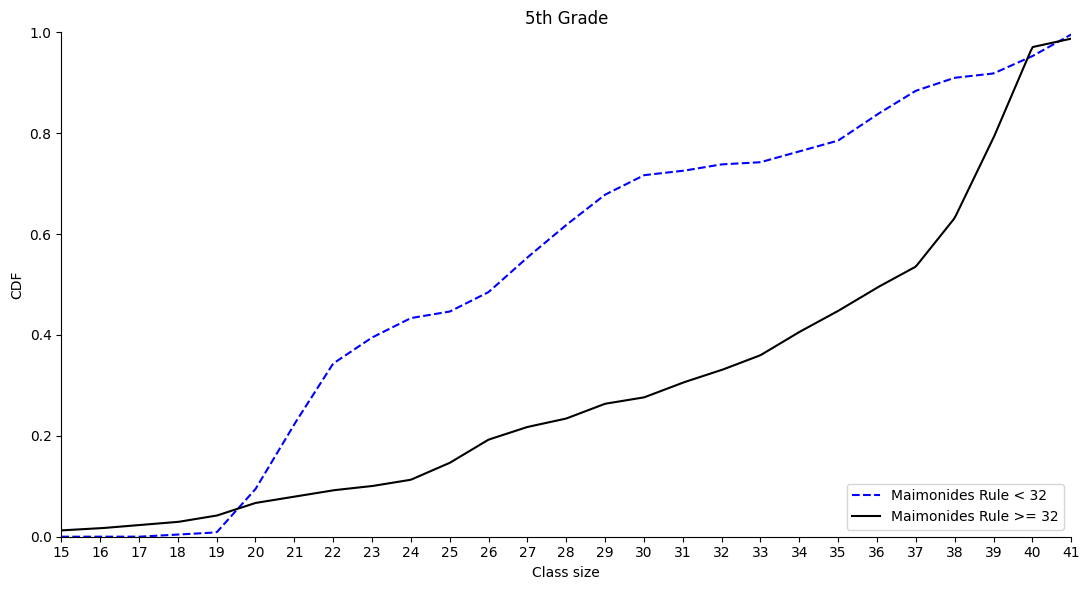

In [44]:
df_5th.plot_cdf_by_instrument()

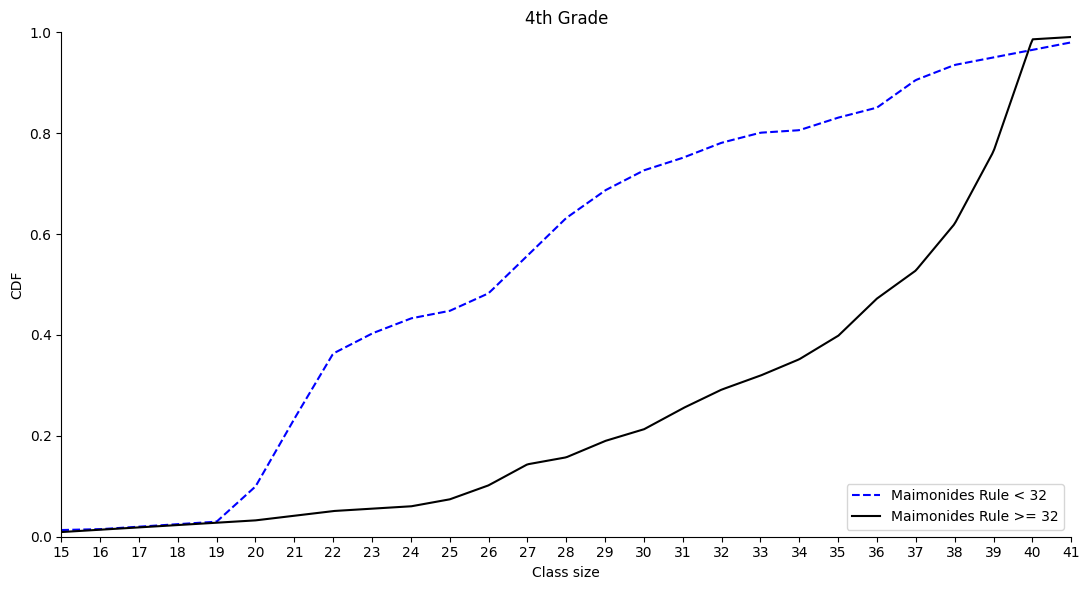

In [45]:
df_4th.plot_cdf_by_instrument()

Angrist and Lavy also compare their study results to previous studies, for example the Tennessee STAR experiment, a benchmark of class size surveys. Their class effect size is $0.29\sigma$ in the distribution of class means, compared to STAR's $0.32\sigma-0.66\sigma$. Angrist and Lavy admit that their result is at the lower end of STAR's findings, and argue that it is still significant because their data is more centralized. The gap between quartiles and the median reading score for class averages of Israeli 5th graders are less than two-thirds of a standard deviation.

# VII. Robustness Check

As I discuss in the previous sections, Angrist and Lavy use various validity checks and alternative specifications to enhance the reliability of their study. It is not perfect though. For instance, the assumption that all smooth effects are adequately controlled by the school characteristic vector is untestable. In this section, I will run a placebo threshold test to check its internal validity.

Instead of setting the Maimonides rule threshold at 40, I adopt a placebo threshold of 30 and run the 2SLS regression. I expect to find no significant correlation between the fake instrument and average test score. If I do, this means that the original study picks up a general enrollment noise, rather than the specific rule.

With a threshold of 30, the class size function derived from Maimonides' rule changes to:
$$
f_{sc}=\frac{e_s}{\lfloor((e_s-1)/30)+1\rfloor}
$$
And the piecewise linear trend changes to:
$$
f(e_s) = \begin{cases} 
e_s & e_s \in [0, 30] \\
15 + (e_s/2) & e_s \in [31, 60] \\
25 + (e_s/3) & e_s \in [61, 90] \\
32.5 + (e_s/4) & e_s \in [91, 120] \\
38.5 + (e_s/5) & e_s \in [121, 150] \\
43.5 + (e_s/6) & e_s \in [151, 180]
\end{cases}
$$

In [48]:
df_5th.custom_twoSLS_table_piecewise(threshold=30)

GT(_tbl_data=                Regressors     (1)      (2)      (3)      (4)     (5)  \
0               Mean score             74.4                      74.4   
1                   (s.d.)            (8.1)                     (8.6)   
2               Regressors                                              
3               Class size    .014    2.039    2.056    1.221   1.294   
4                           (.060)  (2.231)  (2.258)  (2.165)  (.916)   
5    Percent disadvantaged   -.339    -.231    -.230            -.089   
6                           (.015)   (.130)   (.132)           (.175)   
7               Enrollment                                              
8                                                                       
9   Enrollment squared/100                      .002                    
10                                            (.005)                    
11  Piecewise linear trend            -.657    -.667    -.299           
12                                   (.696)   (.709)   (.721)           
13                Root MSE    6.64    11.82    11.89     9.52    9.66   
14                       N            2,024                       622   

        (6)     (7)      (8)      (9)     (10)     (11)     (12)  
0                                67.3              67.1           
1                              (10.0)            (10.5)           
2                                                                 
3    -2.307    .242    1.819    1.849    1.039    1.923   -2.593  
4   (1.888)  (.081)  (2.330)  (2.363)  (2.419)  (1.223)  (2.197)  
5     -.602   -.304    -.220    -.218              .000    -.643  
6    (.221)  (.020)   (.136)   (.139)            (.233)   (.258)  
7                                                                 
8                                                                 
9                                .003                             
10                             (.005)                             
11     .465            -.512    -.529    -.171              .584  
12   (.395)           (.727)   (.742)   (.806)            (.459)  
13    12.68    8.92    12.35    12.45    10.64    12.90    14.76  
14                              2,024               622           , _body=<great_tables._gt_data.Body object at 0x0000028B4B93B4D0>, _boxhead=Boxhead([ColInfo(var='Regressors', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='(1)', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='(2)', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='(3)', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='(4)', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='(5)', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='(6)', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None), ColInfo(var='(7)', type=<ColInfoTypeEnum.default: 1>, column_label='(7)', column_align='center', column_width=None), ColInfo(var='(8)', type=<ColInfoTypeEnum.default: 1>, column_label='(8)', column_align='center', column_width=None), ColInfo(var='(9)', type=<ColInfoTypeEnum.default: 1>, column_label='(9)', column_align='center', column_width=None), ColInfo(var='(10)', type=<ColInfoTypeEnum.default: 1>, column_label='(10)', column_align='center', column_width=None), ColInfo(var='(11)', type=<ColInfoTypeEnum.default: 1>, column_label='(11)', column_align='center', column_width=None), ColInfo(var='(12)', type=<ColInfoTypeEnum.default: 1>, column_label='(12)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028B4940EF30>, _spanners=Spanners([SpannerInfo(spanner_id='Reading comprehension'

The table above shows the 2SLS regression results based on a threshold of 30. All standard errors in this table are massive, indicating that its results are insignificant. The fake instrumental variable fails to shift the acutal class size in any meaningful way. Thus, it can be concluded that the findings of Angrist and Lavy's paper are not a placebo effect.

# VIII. Conclusion

This project successfully replicates the findings of Angrist and Lavy, confirming the negative causal relationship between class size and student achievement. By utilizing Maimonides' rule as an instrumental variable, this replication identifies the effect of class sizer while partialling out confounding factors like enrollment and socioeconomic status.

Reduced-form estimates and 2SLS regressions consistently show that decreasing class size improves test scores for 4th and 5th graders. Pooled estimates also show that class size reduction is a powerful tool for closing achievement gaps between poor and wealthy students. The placebo threshold test confirms that the identified effects are unique to the administrative rule of 40, instead of picking up random noises.

While this replication notes some deviation in residual estimates and regression results, the qualitative findings remain identical. The primary identification - the 2SLS regression - remains robust and consistent with the original study.

The findings highlight the diminishing marginal returns effect in education. As the largest treatment effect is found in typical Isreali classes, the findings provide solid empirical basis for policy debates regarding how to improve national education outcomes.

# IX. References

Angrist, J., & Lavy, V. (1999). Using Maimonides’ rule to estimate the effect of class size on student  achievement. The Quarterly Journal of Economics, 114(2), 533–575.

Moulton, B. R. (1986). Random group effects and the precision of regression estimates. Journal of Econometrics, 32(3), 385–397. 